
# 🌦️ Weather Forecasting with Deep Learning Using PyTorch

In this project, we build a complete deep learning pipeline for weather forecasting using Python and PyTorch.


## 📦 Step 1: Import Required Libraries and Initial Setup

In [1]:
# ====================================================
# Step 1: Imports and Initial Setup
# ====================================================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)


## 🌡️ Step 2: Data Acquisition and Initial Preprocessing

In [10]:
# ====================================================
# Step 2: Data Acquisition and Initial Preprocessing
# ====================================================

num_samples_placeholder = 1000
num_features_placeholder = 6

features_placeholder = [
    'temp',
    'humidity',
    'wind',
    'pressure',
    'cloud',
    'season_encoded'
]

X_placeholder = np.random.rand(
    num_samples_placeholder,
    num_features_placeholder
)

y_placeholder = np.random.rand(
    num_samples_placeholder,
    1
)


## 🔄 Step 3: Feature and Target Scaling

In [11]:
# ====================================================
# Step 3: Feature and Target Scaling
# ====================================================

scalerX = StandardScaler()
scalerY = StandardScaler()

# X_scaled = scalerX.fit_transform(X)
# y_scaled = scalerY.fit_transform(y)


## ✂️ Step 4: Train-Test Split and Tensor Conversion

In [12]:
# ====================================================
# Step 4: Data Splitting and Tensor Conversion
# ====================================================

X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor = train_test_split(
    torch.tensor(
        scalerX.fit_transform(X_placeholder),
        dtype=torch.float32
    ),

    torch.tensor(
        scalerY.fit_transform(y_placeholder),
        dtype=torch.float32
    ),

    test_size=0.2,
    random_state=42
)


## 🧠 Step 5: Define Neural Network Architecture

In [13]:
# ====================================================
# Step 5: Define Neural Network Architecture
# ====================================================

class WeatherForecastModel(nn.Module):

    def __init__(self, input_features):
        super(WeatherForecastModel, self).__init__()

        self.fc1 = nn.Linear(input_features, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))

        return self.fc4(x)


## ⚙️ Step 6: Initialize Model, Loss Function, and Optimizer

In [14]:
# ====================================================
# Step 6: Initialize Model, Loss Function, and Optimizer
# ====================================================

model = WeatherForecastModel(
    input_features=len(features_placeholder)
)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

train_losses = []

epoch_predictions = []


## 🏋️ Step 7: Train the Neural Network

In [15]:
# ====================================================
# Step 7: Train the Model
# ====================================================

num_epochs = 100

batch_size = 32

num_batches = len(X_train_tensor) // batch_size

if len(X_train_tensor) % batch_size != 0:
    num_batches += 1

for epoch in range(num_epochs):

    model.train()

    total_loss = 0

    for i in range(0, len(X_train_tensor), batch_size):

        X_batch = X_train_tensor[i:i+batch_size]
        y_batch = y_train_tensor[i:i+batch_size]

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(predictions, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_epoch_loss = total_loss / num_batches

    train_losses.append(avg_epoch_loss)

    model.eval()

    with torch.no_grad():

        train_preds_scaled = model(
            X_train_tensor
        ).detach().cpu().numpy()

        true_vals_scaled = y_train_tensor.cpu().numpy()

        epoch_predictions.append(
            (
                epoch + 1,
                train_preds_scaled,
                true_vals_scaled
            )
        )

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Avg. Train Loss: {avg_epoch_loss:.4f}"
    )


Epoch [1/100], Avg. Train Loss: 0.9627
Epoch [2/100], Avg. Train Loss: 0.9476
Epoch [3/100], Avg. Train Loss: 0.9392
Epoch [4/100], Avg. Train Loss: 0.9311
Epoch [5/100], Avg. Train Loss: 0.9246
Epoch [6/100], Avg. Train Loss: 0.9158
Epoch [7/100], Avg. Train Loss: 0.9071
Epoch [8/100], Avg. Train Loss: 0.8967
Epoch [9/100], Avg. Train Loss: 0.8858
Epoch [10/100], Avg. Train Loss: 0.8753
Epoch [11/100], Avg. Train Loss: 0.8628
Epoch [12/100], Avg. Train Loss: 0.8488
Epoch [13/100], Avg. Train Loss: 0.8328
Epoch [14/100], Avg. Train Loss: 0.8160
Epoch [15/100], Avg. Train Loss: 0.8003
Epoch [16/100], Avg. Train Loss: 0.7829
Epoch [17/100], Avg. Train Loss: 0.7660
Epoch [18/100], Avg. Train Loss: 0.7482
Epoch [19/100], Avg. Train Loss: 0.7294
Epoch [20/100], Avg. Train Loss: 0.7122
Epoch [21/100], Avg. Train Loss: 0.6925
Epoch [22/100], Avg. Train Loss: 0.6769
Epoch [23/100], Avg. Train Loss: 0.6595
Epoch [24/100], Avg. Train Loss: 0.6433
Epoch [25/100], Avg. Train Loss: 0.6269
Epoch [26

## 💾 Step 8: Save the Trained Model

In [16]:
# ====================================================
# Step 8: Save the Trained Model
# ====================================================

torch.save(
    model.state_dict(),
    "weather_forecast_model.pth"
)

print("Model saved as 'weather_forecast_model.pth'")


Model saved as 'weather_forecast_model.pth'


## 🔮 Step 9: Load the Model and Make Predictions

In [17]:
# ====================================================
# Step 9: Evaluate and Predict with the Model
# ====================================================

loaded_model = WeatherForecastModel(
    input_features=len(features_placeholder)
)

loaded_model.load_state_dict(
    torch.load("weather_forecast_model.pth")
)

loaded_model.eval()


WeatherForecastModel(
  (fc1): Linear(in_features=6, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)

## 📉 Visualizing Training Loss

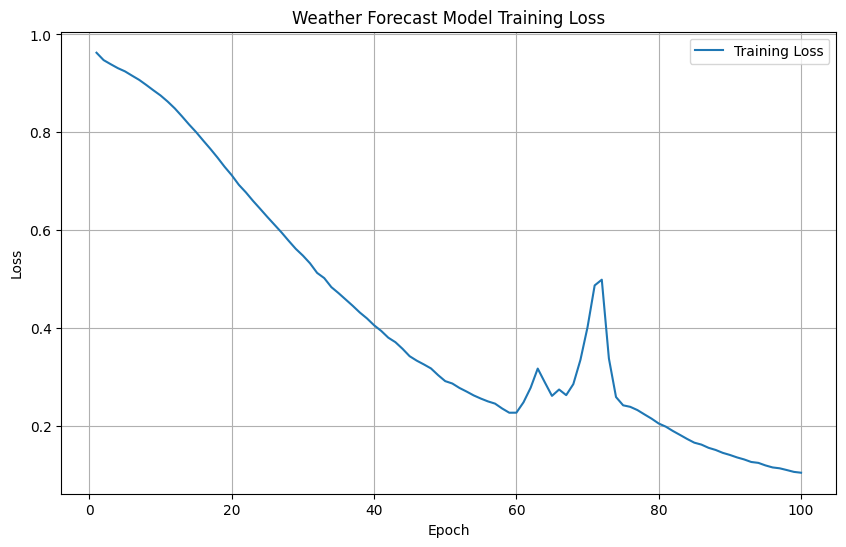

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    label='Training Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Weather Forecast Model Training Loss')

plt.legend()

plt.grid(True)

plt.show()
